<a href="https://colab.research.google.com/github/SaidCondoriRomero/SiS420_Inteligencia_Artificial/blob/main/Laboratorios/Laboratorio_5/Laboratorio_5_PyTorch_Regresion_Lineal_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Laboratorio 5 — PyTorch Regresión Lineal

## Condori Romero Said - Ing Sistemas

## Dataset: Online Video Transcoding
https://archive.ics.uci.edu/dataset/335/online+video+characteristics+and+transcoding+time+dataset

El dataset contiene experimentos de transcodificación de video realizados sobre un procesador Intel i7. Se tomaron videos de YouTube y se transcodificaron a distintos formatos usando ffmpeg. El objetivo es predecir el tiempo que tarda ese proceso (variable utime).

## Objetivo
Aplicar Regresión Lineal con PyTorch para predecir el tiempo de transcodificación de videos, usando las estructuras de Dataset, DataLoader y Checkpoints estudiadas en los cuadernillos PyTorch 02, 03 y 04.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import torch
import torch.nn as nn

# Cálculo científico y vectorial para python
import numpy as np

# Manejo de datos tabulares
import pandas as pd

# Libreria para graficos
from matplotlib import pyplot

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

# Verificar dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", device)

# Semilla para reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

Dispositivo: cuda


## Carga y Preprocesamiento de Datos

Se carga el dataset con Pandas. Se descarta la columna `id` por ser un identificador no predictivo. Las columnas categóricas `codec` y `o_codec` se convierten a variables numéricas mediante one-hot encoding, generando columnas binarias (0/1) para cada valor posible. La variable objetivo `utime` se coloca al final del dataframe.

In [ ]:
# ============================================================
# LABORATORIO 5 — PyTorch Regresión Lineal
# Dataset: Online Video Transcoding
# https://archive.ics.uci.edu/dataset/335/online+video+characteristics+and+transcoding+time+dataset
# ============================================================

ruta = '/content/gdrive/MyDrive/SIS420 Condori Romero Said/datasets/transcoding_mesurment.tsv'

# Cargar con pandas
df = pd.read_csv(ruta, sep='\t')

# Descartar columna no predictiva
df = df.drop(['id'], axis=1)

# One-hot encoding de columnas categoricas
df = pd.get_dummies(df, columns=['codec', 'o_codec'], dtype=float)
df.columns = df.columns.str.replace(' ', '_')

# Reorganizar columnas: utime al final
cols = [c for c in df.columns if c != 'utime'] + ['utime']
df = df[cols]

# Separar X e y
data = df.values.astype(float)
X = data[:, :26]
y = data[:, 26]
m, n = X.shape

print('Dimensiones del dataset:', df.shape)
print('Ejemplos (m):', m)
print('Características (n):', n)
print('Rango de utime: {:.3f} - {:.3f} segundos'.format(y.min(), y.max()))
print()
print('{:>8s}{:>8s}{:>10s}'.format('X[:,0]', 'X[:,1]', 'utime'))
print('-'*26)
for i in range(10):
    print('{:10.3f}{:10.3f}{:10.3f}'.format(X[i, 0], X[i, 1], y[i]))

Dimensiones del dataset: (68784, 27)
Ejemplos (m): 68784
Características (n): 26
Rango de utime: 0.184 - 224.574 segundos

  X[:,0]  X[:,1]     utime
--------------------------
   130.357   176.000     0.612
   130.357   176.000     0.980
   130.357   176.000     1.216
   130.357   176.000     1.692
   130.357   176.000     3.456
   130.357   176.000     6.320
   130.357   176.000     0.728
   130.357   176.000     0.944
   130.357   176.000     1.476
   130.357   176.000     1.964


## División 80% Entrenamiento / 20% Prueba y Normalización

Se divide el dataset en 80% para entrenamiento y 20% para prueba. La normalización Z-score se calcula únicamente con los datos de entrenamiento y se aplica la misma transformación al conjunto de prueba, garantizando que los datos de prueba no influyan en el entrenamiento (sin data leakage).

In [ ]:
# División 80/20 y normalización
np.random.seed(42)
indices = np.random.permutation(m)
corte   = int(0.8 * m)

X_train_raw = X[indices[:corte]]
y_train_raw = y[indices[:corte]]
X_test_raw  = X[indices[corte:]]
y_test_raw  = y[indices[corte:]]

# Normalizar solo con X_train
mu    = np.mean(X_train_raw, axis=0)
sigma = np.std(X_train_raw, axis=0)
sigma[sigma == 0] = 1

X_train_norm = (X_train_raw - mu) / sigma
X_test_norm  = (X_test_raw  - mu) / sigma

print('Entrenamiento (80%):', X_train_norm.shape)
print('Prueba       (20%):', X_test_norm.shape)

Entrenamiento (80%): (55027, 26)
Prueba       (20%): (13757, 26)


## Conversión a Tensores PyTorch

Se convierten los arrays de NumPy a tensores de PyTorch y se mueven a la GPU con `.to(device)`. El método `.unsqueeze(1)` cambia el shape de `y` de `(m,)` a `(m,1)` para que sea compatible con la capa de salida del modelo.

In [ ]:
# Convertir a tensores PyTorch y mover a GPU
X_train_t = torch.from_numpy(X_train_norm).float().to(device)
y_train_t = torch.from_numpy(y_train_raw).float().unsqueeze(1).to(device)
X_test_t  = torch.from_numpy(X_test_norm).float().to(device)
y_test_t  = torch.from_numpy(y_test_raw).float().unsqueeze(1).to(device)

print('X_train_t shape:', X_train_t.shape)
print('y_train_t shape:', y_train_t.shape)
print('X_test_t  shape:', X_test_t.shape)
print('y_test_t  shape:', y_test_t.shape)

X_train_t shape: torch.Size([55027, 26])
y_train_t shape: torch.Size([55027, 1])
X_test_t  shape: torch.Size([13757, 26])
y_test_t  shape: torch.Size([13757, 1])


## Dataset y DataLoader (cuadernillo PyTorch 03)

Se implementa la clase `Dataset` de PyTorch para encapsular los datos definiendo `__init__`, `__len__` y `__getitem__`. El `DataLoader` permite iterar en minibatches de 512 ejemplos, mezclando los datos en cada época durante el entrenamiento con `shuffle=True`. Esto permite procesar los datos de forma eficiente en GPU.

In [ ]:

class TranscodingDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.y[ix]

# Crear datasets
train_dataset = TranscodingDataset(X_train_t, y_train_t)
test_dataset  = TranscodingDataset(X_test_t,  y_test_t)

# Crear DataLoaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=512, shuffle=False)

print('Batches entrenamiento:', len(train_loader))
print('Batches prueba:       ', len(test_loader))

Batches entrenamiento: 108
Batches prueba:        27


## Modelo de Regresión Lineal (cuadernillo PyTorch 02)

Se define el modelo como una clase que hereda de `nn.Module`. La arquitectura es una única capa lineal `nn.Linear(26, 1)` que aprende los 26 parámetros theta más el término de sesgo, equivalente a la regresión lineal multivariable del Lab 2. La función `forward` define el flujo de datos a través del modelo.

In [ ]:

class RegresionLineal(nn.Module):
    def __init__(self, input_size):
        super(RegresionLineal, self).__init__()
        self.fc = nn.Linear(input_size, 1)

    def forward(self, x):
        return self.fc(x)

modelo = RegresionLineal(input_size=n).to(device)
print(modelo)

# Verificar dimensiones
x_prueba = torch.randn(10, n).to(device)
salida = modelo(x_prueba)
print('Salida de prueba shape:', salida.shape)

RegresionLineal(
  (fc): Linear(in_features=26, out_features=1, bias=True)
)
Salida de prueba shape: torch.Size([10, 1])


## Entrenamiento con Checkpoints (cuadernillo PyTorch 04)

Se usa `MSELoss` como función de pérdida y `Adam` como optimizador. En cada época se ejecuta el forward pass calculando la predicción, se calcula el error con la función de pérdida, se obtienen los gradientes con `loss.backward()` y se actualizan los pesos con `optimizer.step()`. El mejor modelo se guarda en Google Drive usando `torch.save()` cuando el `test_loss` mejora, siguiendo la estrategia de checkpoints del cuadernillo PyTorch 04.

In [ ]:
# Funcion de perdida y optimizador (del cuadernillo PyTorch 02)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(modelo.parameters(), lr=0.001)

# Ruta para guardar el mejor modelo (del cuadernillo PyTorch 04)
PATH_checkpoint = '/content/gdrive/MyDrive/SIS420 Condori Romero Said/datasets/mejor_modelo_transcoding_lineal.pt'

# Entrenamiento
epochs       = 200
log_each     = 20
train_losses = []
test_losses  = []
best_loss    = float('inf')

for e in range(1, epochs + 1):

    _train_loss = []
    modelo.train()
    for x_b, y_b in train_loader:
        optimizer.zero_grad()
        y_pred = modelo(x_b)
        loss   = criterion(y_pred, y_b)
        loss.backward()
        optimizer.step()
        _train_loss.append(loss.item())

    _test_loss = []
    modelo.eval()
    with torch.no_grad():
        for x_b, y_b in test_loader:
            y_pred = modelo(x_b)
            loss   = criterion(y_pred, y_b)
            _test_loss.append(loss.item())

    train_loss = np.mean(_train_loss)
    test_loss  = np.mean(_test_loss)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if test_loss < best_loss:
        best_loss = test_loss
        torch.save(modelo.state_dict(), PATH_checkpoint)
        print(f'Epoch {e:3d}/{epochs} — Mejor modelo guardado — train_loss: {train_loss:.4f} test_loss: {test_loss:.4f}')

    if not e % log_each:
        print(f'Epoch {e:3d}/{epochs} — train_loss: {train_loss:.4f} test_loss: {test_loss:.4f}')

print('\nEntrenamiento completado. Mejor test_loss: {:.4f}'.format(best_loss))

Epoch   1/200 — Mejor modelo guardado — train_loss: 346.3416 test_loss: 336.3155
Epoch   2/200 — Mejor modelo guardado — train_loss: 334.2315 test_loss: 324.7163
Epoch   3/200 — Mejor modelo guardado — train_loss: 323.5004 test_loss: 313.9087
Epoch   4/200 — Mejor modelo guardado — train_loss: 312.2015 test_loss: 303.6521
Epoch   5/200 — Mejor modelo guardado — train_loss: 301.9120 test_loss: 293.9716
Epoch   6/200 — Mejor modelo guardado — train_loss: 293.9446 test_loss: 284.8543
Epoch   7/200 — Mejor modelo guardado — train_loss: 284.3260 test_loss: 276.0390
Epoch   8/200 — Mejor modelo guardado — train_loss: 275.3436 test_loss: 267.7022
Epoch   9/200 — Mejor modelo guardado — train_loss: 267.6968 test_loss: 259.6849
Epoch  10/200 — Mejor modelo guardado — train_loss: 260.0855 test_loss: 252.0323
Epoch  11/200 — Mejor modelo guardado — train_loss: 251.6820 test_loss: 244.7705
Epoch  12/200 — Mejor modelo guardado — train_loss: 244.4362 test_loss: 237.7871
Epoch  13/200 — Mejor modelo

## Gráfica de Convergencia del Costo

Se carga el mejor modelo guardado con `torch.load()` siguiendo la práctica del cuadernillo PyTorch 04. Se visualiza la curva de costo por época. Ambas curvas (entrenamiento y prueba) deben bajar juntas — si se separan indica overfitting, es decir que el modelo memoriza los datos de entrenamiento en lugar de aprender patrones generalizables.

Mejor modelo cargado correctamente


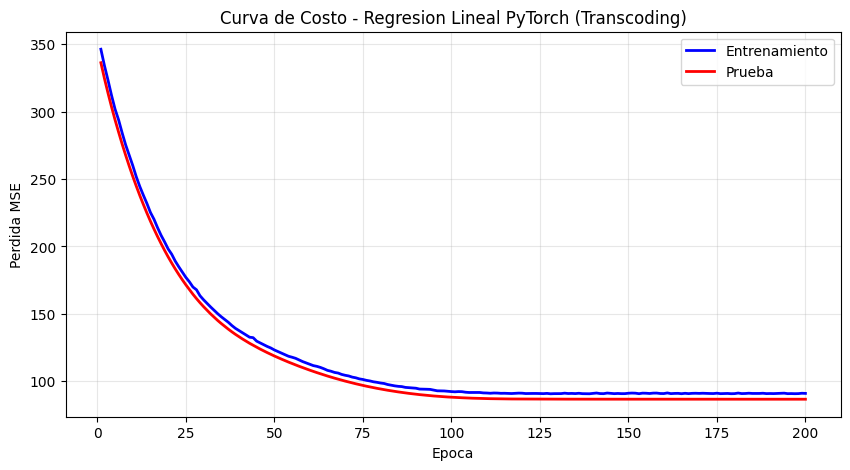

In [ ]:
# Cargar el mejor modelo (del cuadernillo PyTorch 04)
modelo.load_state_dict(torch.load(PATH_checkpoint))
modelo.eval()
print('Mejor modelo cargado correctamente')

# Grafica de convergencia del costo
pyplot.figure(figsize=(10, 5))
pyplot.plot(range(1, epochs + 1), train_losses, 'b-', label='Entrenamiento', linewidth=2)
pyplot.plot(range(1, epochs + 1), test_losses,  'r-', label='Prueba',        linewidth=2)
pyplot.xlabel('Epoca')
pyplot.ylabel('Perdida MSE')
pyplot.title('Curva de Costo - Regresion Lineal PyTorch (Transcoding)')
pyplot.legend()
pyplot.grid(True, alpha=0.3)
pyplot.show()

## Predicciones sobre el Conjunto de Prueba

Se generan predicciones sobre el 20% de datos que el modelo nunca vio durante el entrenamiento. Se calcula el Error Absoluto Medio (MAE) para comparar con los métodos del Lab 2. El modelo está en modo `eval()` y se usa `torch.no_grad()` para no calcular gradientes innecesarios durante la inferencia.

In [ ]:
# Predicciones sobre el conjunto de prueba
modelo.eval()
with torch.no_grad():
    predicciones = modelo(X_test_t).cpu().numpy().flatten()

# Mostrar comparacion igual que el laboratorio base
print('{:>5s}{:>12s}{:>14s}{:>12s}'.format('Ej', 'Real (s)', 'Predicho', 'Error'))
print('-' * 45)
for i in range(20):
    error = abs(y_test_raw[i] - predicciones[i])
    print('{:>5d}{:>12.3f}{:>14.3f}{:>12.3f}'.format(i+1, y_test_raw[i], predicciones[i], error))

mae = np.mean(np.abs(y_test_raw - predicciones))
print()
print('Error Absoluto Medio (MAE): {:.4f} segundos'.format(mae))

   Ej    Real (s)      Predicho       Error
---------------------------------------------
    1       6.084         8.834       2.750
    2       5.216         8.167       2.951
    3       4.100        10.275       6.175
    4       3.900         3.226       0.674
    5      41.387        26.191      15.196
    6       3.404         7.044       3.640
    7       4.408         6.723       2.315
    8      14.133        18.979       4.846
    9       0.348        -3.728       4.076
   10       2.676         8.198       5.522
   11       0.864        -8.528       9.392
   12       5.108        12.653       7.545
   13       3.664         3.603       0.061
   14      32.206        14.578      17.628
   15       2.244         1.325       0.919
   16      10.541        14.429       3.888
   17       7.872        10.043       2.171
   18       1.916         6.199       4.283
   19       2.224         1.694       0.530
   20       2.140         6.932       4.792

Error Absoluto Medio (MAE): 5

## Gráfica de Predicciones vs Valores Reales

Se comparan visualmente las predicciones del modelo contra los valores reales sobre 20 ejemplos del conjunto de prueba. La curva roja debe seguir el patrón de la curva negra — las diferencias indican el error del modelo. Esta comparativa permite identificar si el modelo falla más en valores extremos (picos altos de utime).

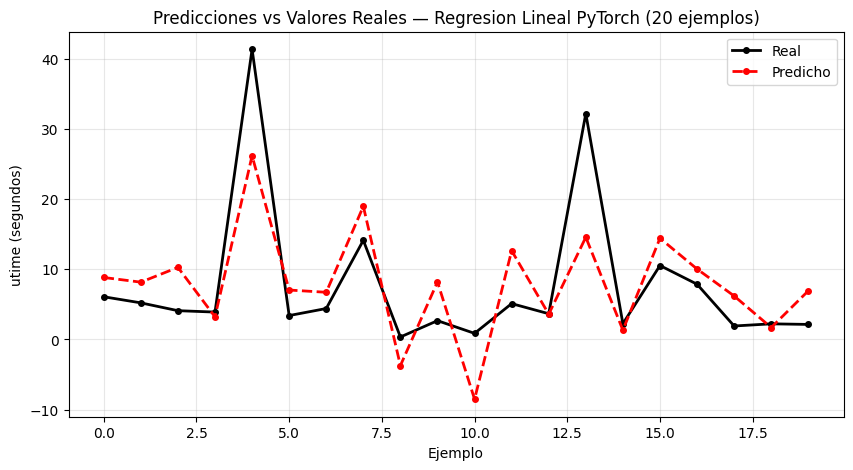

Error Absoluto Medio (MAE): 5.6588 segundos


In [ ]:
# Grafica Real vs Predicho
pyplot.figure(figsize=(10, 5))
pyplot.plot(range(20), y_test_raw[:20], 'k-o', label='Real',     linewidth=2, markersize=4)
pyplot.plot(range(20), predicciones[:20], 'r--o', label='Predicho', linewidth=2, markersize=4)
pyplot.xlabel('Ejemplo')
pyplot.ylabel('utime (segundos)')
pyplot.title('Predicciones vs Valores Reales — Regresion Lineal PyTorch (20 ejemplos)')
pyplot.legend()
pyplot.grid(True, alpha=0.3)
pyplot.show()

print('Error Absoluto Medio (MAE): {:.4f} segundos'.format(mae))